In [15]:
# Import needed python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ctgan import CTGAN
from imblearn.over_sampling import RandomOverSampler

In [16]:
# Loading the classification dataset
data = pd.read_csv('drug.csv')

In [17]:
# Display the first few rows of the dataset
data.head() 

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [18]:
# Shape of the dataset
data.shape

(200, 6)

In [19]:
# As we have only 200 data we can use CTGAN to generate more data
# lest seperate categorical columns
cat = ["Sex", "BP", "Cholesterol", "Drug"]

# Initialize CTGAN model
ctgan = CTGAN(epochs=300)

# Fit the model on the original data
ctgan.fit(data, discrete_columns=cat)

# Generate synthetic data
synthetic_data = ctgan.sample(1000)

# Combine original and synthetic data
combined_data = pd.concat([data, synthetic_data], ignore_index=True)

# Check the shape of the combined data
combined_data.shape


(1200, 6)

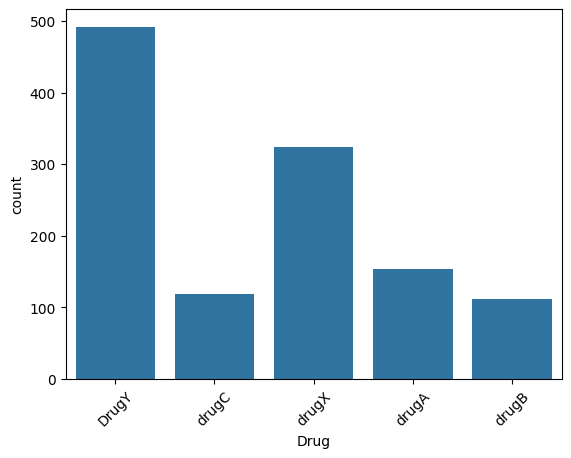

In [20]:
# Check class distribution for new combined data
sns.countplot(data=combined_data, x="Drug")
plt.xticks(rotation=45)
plt.show()


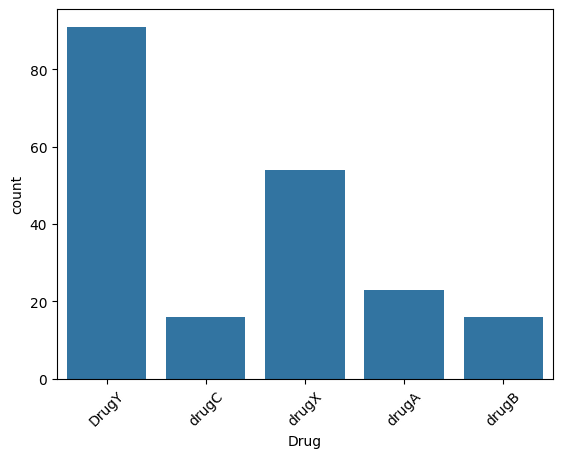

In [21]:
# Check class distribution for original data
sns.countplot(data=data, x="Drug")
plt.xticks(rotation=45)
plt.show()


In [22]:
# Describe the combined data
combined_data.describe()

,Age,Na_to_K
count,1200.000000,1200.000000
mean,57.515000,17.097247
std,20.266567,7.449682
min,4.000000,4.000406
25%,43.000000,12.785376
50%,58.000000,15.699010
75%,74.000000,18.882444
max,96.000000,48.687559


In [23]:
# Lets use MAD for Noise management
df = combined_data.copy()


In [24]:
df.shape

(1200, 6)

In [ ]:
# i applied differenent experiments on it
# Change the Threshold Value , I applied lower values and also bigger values as well

# by using "series.mean()" Before remove noises we had 1200 data whereas after remove noises we have 1183 data. This method becomes mean absolute deviation from mean, not from median.

# Change MAD formula constant. modified_z_scores = 0.7 * (series - median) / mad.
# Slightly changes the scale of z-scores and some borderline values may become outliers or non-outliers depending on scaling.

# Here is my best results that I got and expererienced.

# Before remove noises we had 1200 data whereas after remove noises we have 1129 data.

In [26]:
# Creating a function to identify outliers using MAD
# Z score beyond threshold will be considered as outlier
def mad_outliers(series, threshold=3.5):
    
    median = series.median()
    mad = np.median(np.abs(series - median))

    # In case all values are the same, then No outliers
    if mad == 0:
        return pd.Series([False]*len(series))
    
    # For other cases lets see if z score is beyond threshold---> if yes the outlier_mask true
    modified_z_scores = 0.6745 * (series - median) / mad
    return np.abs(modified_z_scores) > threshold

# Apply MAD to numeric columns
numeric_cols = ['Age', 'Na_to_K']

# Making a new dataframe which has outlier mask true or false
outlier_mask = pd.DataFrame({
    col: mad_outliers(df[col])
    for col in numeric_cols
})

# Find rows with any outlier for given colums and making a data series called rows_with_outlier from the dataframe called outlier_mask
rows_with_outlier = outlier_mask.any(axis=1)

# Remove noise/outliers
clean_df = df[~rows_with_outlier]

In [27]:
# We have new dataframe now 
clean_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [28]:
clean_df.shape

(1129, 6)

Before remove noises we had 1200 data whereas after remove noises we have 1129 data